# 3. An ARX model for the heating of a box

The final part is about identifying a suitable ARX model for predicting the hourly heating of a test
box (a small building). The box has a window in the south facing wall.

In an experiment times series were recorded of the variables:
- $P_h$ (*Ph* in data) the heat from electrical heaters (W).
- $T_{delta}$ (*Tdelta* in data) the difference between the internal and external temperature (◦C)
- $G_v$ (*Gv* in data) the vertical solar radiation onto the box side with a window (W/m2)

The data consists of average hourly values – in total 231 hours. It’s available in the *box_data_60min.csv*
file.

In the experiment the internal air temperature was kept constant with a thermostatic control of the
heating – hence the heating change depending on the weather conditions.

The objective is to find a suitable model, which makes good predictions of the heating.

Lags have been generated and included in the data with a naming syntax such that, e.g.: *Ph.l1* is the
heating lagged one step, *Ph.l2* is heating lagged two steps and so fourth.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

### 3.1. Read the data and plot the three non-lagged time series (*Ph*, *Tdelta*, *Gv*). Describe the time series and if you can see some dependencies between the variables.

#### Load the data

In [68]:
from pathlib import Path
print(Path.cwd())

c:\Users\manon\OneDrive\Bureau\Danemark\DTU\Spring 2026\02417 Time Series Analysis\02417---Time-Series-Analysis\assignments\Assignment3


In [69]:
df = pd.read_csv(r'C:\Users\manon\OneDrive\Bureau\Danemark\DTU\Spring 2026\02417 Time Series Analysis\02417---Time-Series-Analysis\assignments\Assignment3\assignment3_2026\box_data_60min.csv')

In [70]:
print(df.columns)
print(df.head)

Index(['thour', 'tdate', 'Ph', 'Tdelta', 'Gv', 'Ph.l0', 'Ph.l1', 'Ph.l2',
       'Ph.l3', 'Ph.l4', 'Ph.l5', 'Ph.l6', 'Ph.l7', 'Ph.l8', 'Ph.l9', 'Ph.l10',
       'Tdelta.l0', 'Tdelta.l1', 'Tdelta.l2', 'Tdelta.l3', 'Tdelta.l4',
       'Tdelta.l5', 'Tdelta.l6', 'Tdelta.l7', 'Tdelta.l8', 'Tdelta.l9',
       'Tdelta.l10', 'Gv.l0', 'Gv.l1', 'Gv.l2', 'Gv.l3', 'Gv.l4', 'Gv.l5',
       'Gv.l6', 'Gv.l7', 'Gv.l8', 'Gv.l9', 'Gv.l10'],
      dtype='object')
<bound method NDFrame.head of      thour                tdate  Ph     Tdelta          Gv  Ph.l0  Ph.l1  \
0       19  2013-01-30 02:00:00  56  13.253583   -0.498643     56     55   
1       20  2013-01-30 03:00:00  54  13.181458   -1.127035     54     56   
2       21  2013-01-30 04:00:00  55  12.968792   -0.643298     55     54   
3       22  2013-01-30 05:00:00  54  12.667750   -0.456008     54     55   
4       23  2013-01-30 06:00:00  54  12.605250   -1.534060     54     54   
..     ...                  ...  ..        ...         ...    ...

#### Create the plot

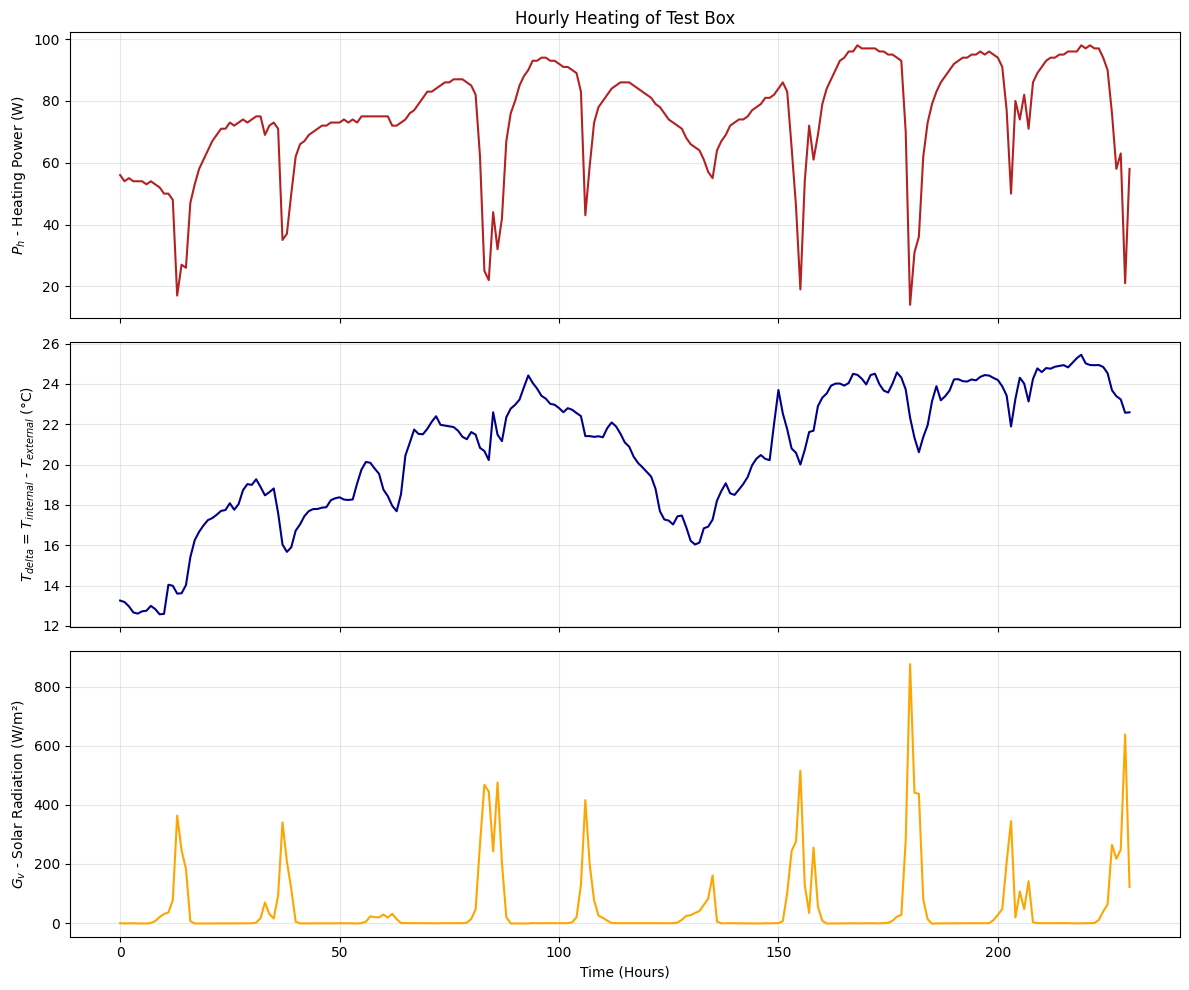

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot Heating Power (Ph)
axes[0].plot(df['Ph'], color='firebrick', linewidth=1.5)
axes[0].set_ylabel('$P_h$ - Heating Power (W)')
axes[0].set_title('Hourly Heating of Test Box')
axes[0].grid(True, alpha=0.3)

# Plot Temperature Difference (Tdelta)
axes[1].plot(df['Tdelta'], color='darkblue', linewidth=1.5)
axes[1].set_ylabel('$T_{delta}$ = $T_{internal}$ - $T_{external}$ (°C)')
axes[1].grid(True, alpha=0.3)

# Plot Solar Radiation (Gv)
axes[2].plot(df['Gv'], color='orange', linewidth=1.5)
axes[2].set_ylabel('$G_v$ - Solar Radiation (W/m²)')
axes[2].set_xlabel('Time (Hours)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2. Split the data into a train and test set, such that ”2013-02-06 00:00” is the last data point in the training set (i.e. $t_{hour}$ = 1, ..., 167 is the training set). From now on, work only on the training set, except where explicitly told to use the test set.

#### Split the data

In [72]:
# Define the split point
train_size = 167

# Split the data
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

#### Verification

In [73]:
# Verify the split
print(f"Training set: {train_df.shape[0]} samples")
print(f"Test set:     {test_df.shape[0]} samples")

# Display the last timestamp of the training set to ensure it matches "2013-02-06 00:00"
final_timestamp = train_df['tdate'].iloc[-1]
print(f"Last training timestamp: {final_timestamp}")

Training set: 167 samples
Test set:     64 samples
Last training timestamp: 2013-02-06 00:00:00


### 3.3. Investigate the variables and their relations: e.g. with scatter, auto-correlation and cross-correlation plots. Most focus on $P_h$. Highlight key aspects of the dynamics and interrelationships among the variables. What can be seen directly and what cannot?

In [74]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#### Scatter Plots with Regression Lines

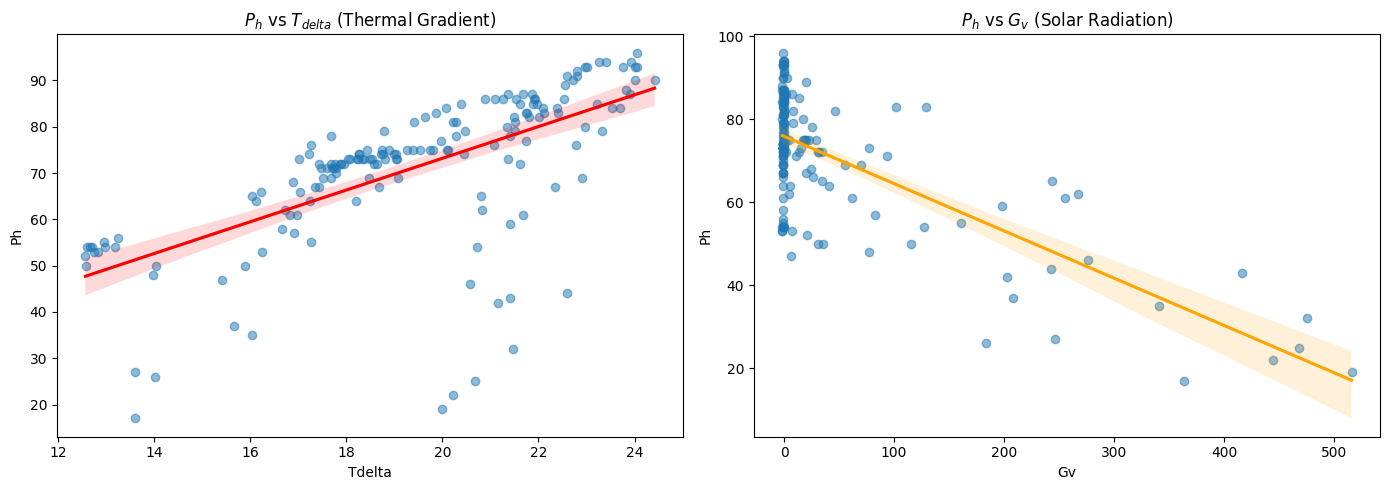

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=train_df, x='Tdelta', y='Ph', ax=ax[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax[0].set_title('$P_h$ vs $T_{delta}$ (Thermal Gradient)')

sns.regplot(data=train_df, x='Gv', y='Ph', ax=ax[1], scatter_kws={'alpha':0.5}, line_kws={'color':'orange'})
ax[1].set_title('$P_h$ vs $G_v$ (Solar Radiation)')
plt.tight_layout()
plt.show()

#### Auto-correlation (ACF) and Partial Auto-correlation (PACF) for $P_h$

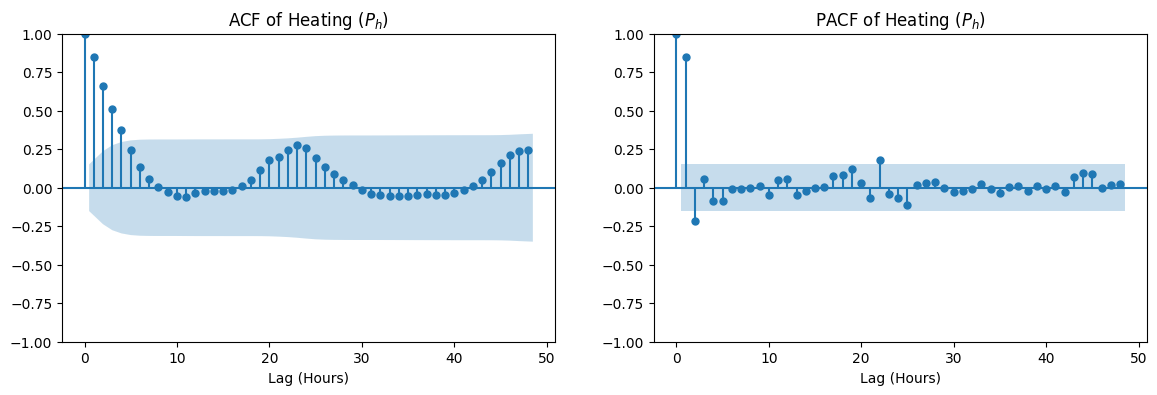

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_df['Ph'], lags=48, ax=ax[0], title='ACF of Heating ($P_h$)')
plot_pacf(train_df['Ph'], lags=48, ax=ax[1], title='PACF of Heating ($P_h$)')
ax[0].set_xlabel('Lag (Hours)')
ax[1].set_xlabel('Lag (Hours)')
plt.show()

#### Cross-correlation (CCF)

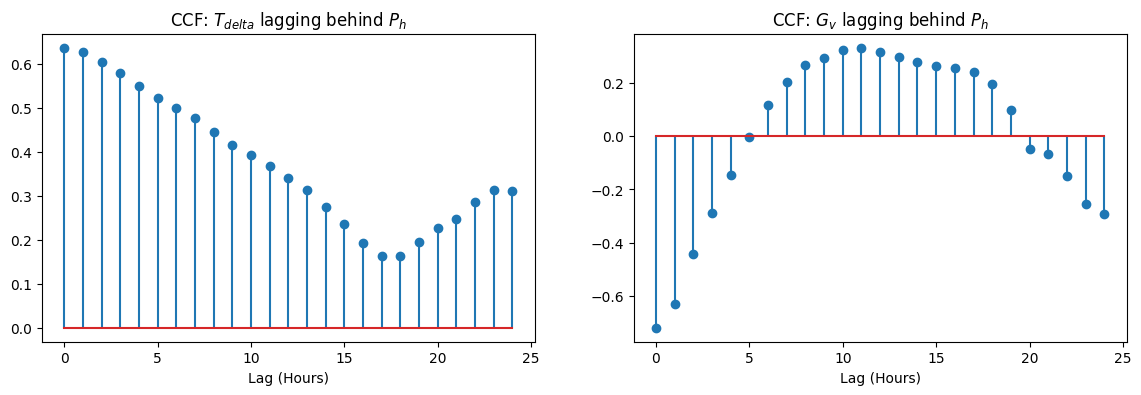

In [77]:
# ccf(x, y) shows how x at time t correlates with y at time t+k
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# CCF: Tdelta and Ph
ccf_tdelta = [train_df['Ph'].corr(train_df['Tdelta'].shift(i)) for i in range(25)]
ax[0].stem(range(25), ccf_tdelta)
ax[0].set_title('CCF: $T_{delta}$ lagging behind $P_h$')
ax[0].set_xlabel('Lag (Hours)')

# CCF: Gv and Ph
ccf_gv = [train_df['Ph'].corr(train_df['Gv'].shift(i)) for i in range(25)]
ax[1].stem(range(25), ccf_gv)
ax[1].set_title('CCF: $G_v$ lagging behind $P_h$')
ax[1].set_xlabel('Lag (Hours)')
plt.show()

### 3.4. Estimate the impulse response from $T_{delta}$ and $G_v$ to $P_h$ make it up to lag 10. Present it for both variables in plots and comment.

In [78]:
import statsmodels.api as sm

In [79]:
def estimate_irf(target, exogenous, max_lag=10):
    # Create a DataFrame for the lagged exogenous variables
    lag_cols = pd.DataFrame(index=target.index)
    for i in range(max_lag + 1):
        lag_cols[f'lag_{i}'] = exogenous.shift(i)
    
    # Drop rows with NaN from shifting
    valid_data = pd.concat([target, lag_cols], axis=1).dropna()
    
    y = valid_data[target.name]
    X = valid_data.drop(columns=[target.name])
    X = sm.add_constant(X) # Include intercept
    
    model = sm.OLS(y, X).fit()
    # Return coefficients for lag_0 to lag_10 (skipping the constant)
    return model.params[1:], model.bse[1:]

# Calculate IRFs (Impulse Response Functions) using the training data
irf_tdelta, stderr_tdelta = estimate_irf(train_df['Ph'], train_df['Tdelta'], max_lag=10)
irf_gv, stderr_gv = estimate_irf(train_df['Ph'], train_df['Gv'], max_lag=10)

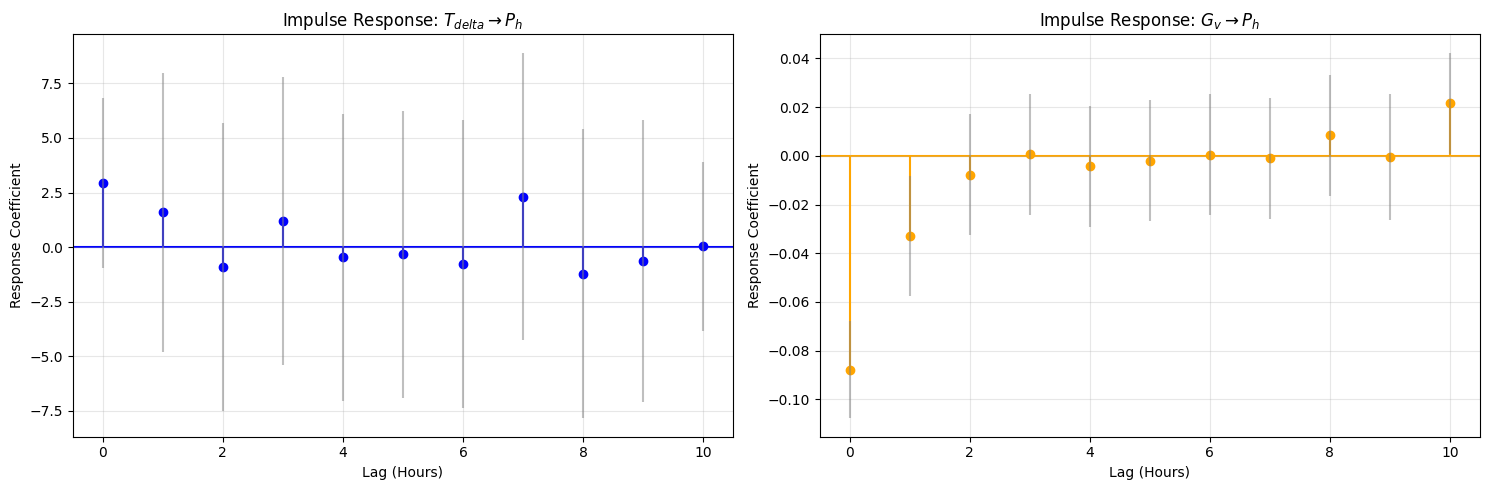

In [80]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot for Tdelta
axes[0].stem(range(11), irf_tdelta, basefmt=" ", linefmt='blue')
axes[0].errorbar(range(11), irf_tdelta, yerr=1.96*stderr_tdelta, fmt='none', ecolor='gray', alpha=0.5)
axes[0].axhline(0, color='blue', linewidth=1.5, zorder=1)
axes[0].set_title('Impulse Response: $T_{delta} \\rightarrow P_h$')
axes[0].set_xlabel('Lag (Hours)')
axes[0].set_ylabel('Response Coefficient')
axes[0].grid(True, alpha=0.3)

# Plot for Gv
axes[1].stem(range(11), irf_gv, basefmt=" ", linefmt='orange')
axes[1].errorbar(range(11), irf_gv, yerr=1.96*stderr_gv, fmt='none', ecolor='gray', alpha=0.5)
axes[1].axhline(0, color='orange', linewidth=1.5, zorder=1)
axes[1].set_title('Impulse Response: $G_v \\rightarrow P_h$')
axes[1].set_xlabel('Lag (Hours)')
axes[1].set_ylabel('Response Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5. Fit the linear regression model $P_{h,t} = ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t$. The error is assumed $ε_t ∼ N (0, σ^2)$ and i.i.d. Analyse the estimation result, one-step prediction, residuals with plots, ACF and CCF. Comment with focus on the potential need for a model which includes a transfer function.

#### Fit the Linear Regression Model (Static)

In [81]:
X = train_df[['Tdelta', 'Gv']]
X = sm.add_constant(X)
y = train_df['Ph']

model_static = sm.OLS(y, X).fit()
train_df['pred_static'] = model_static.predict(X)
train_df['residuals'] = model_static.resid

In [82]:
print(model_static.summary())

                            OLS Regression Results                            
Dep. Variable:                     Ph   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     722.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           4.73e-82
Time:                        11:45:06   Log-Likelihood:                -510.21
No. Observations:                 167   AIC:                             1026.
Df Residuals:                     164   BIC:                             1036.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1484      2.642      4.220      0.0

#### Visualization: Predictions and Residuals

<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
C:\Users\manon\AppData\Local\Temp\ipykernel_44088\444078355.py:12: SyntaxWarning: invalid escape sequence '\e'
  axes[0,1].set_title('Residuals $\epsilon_t$ over Time')


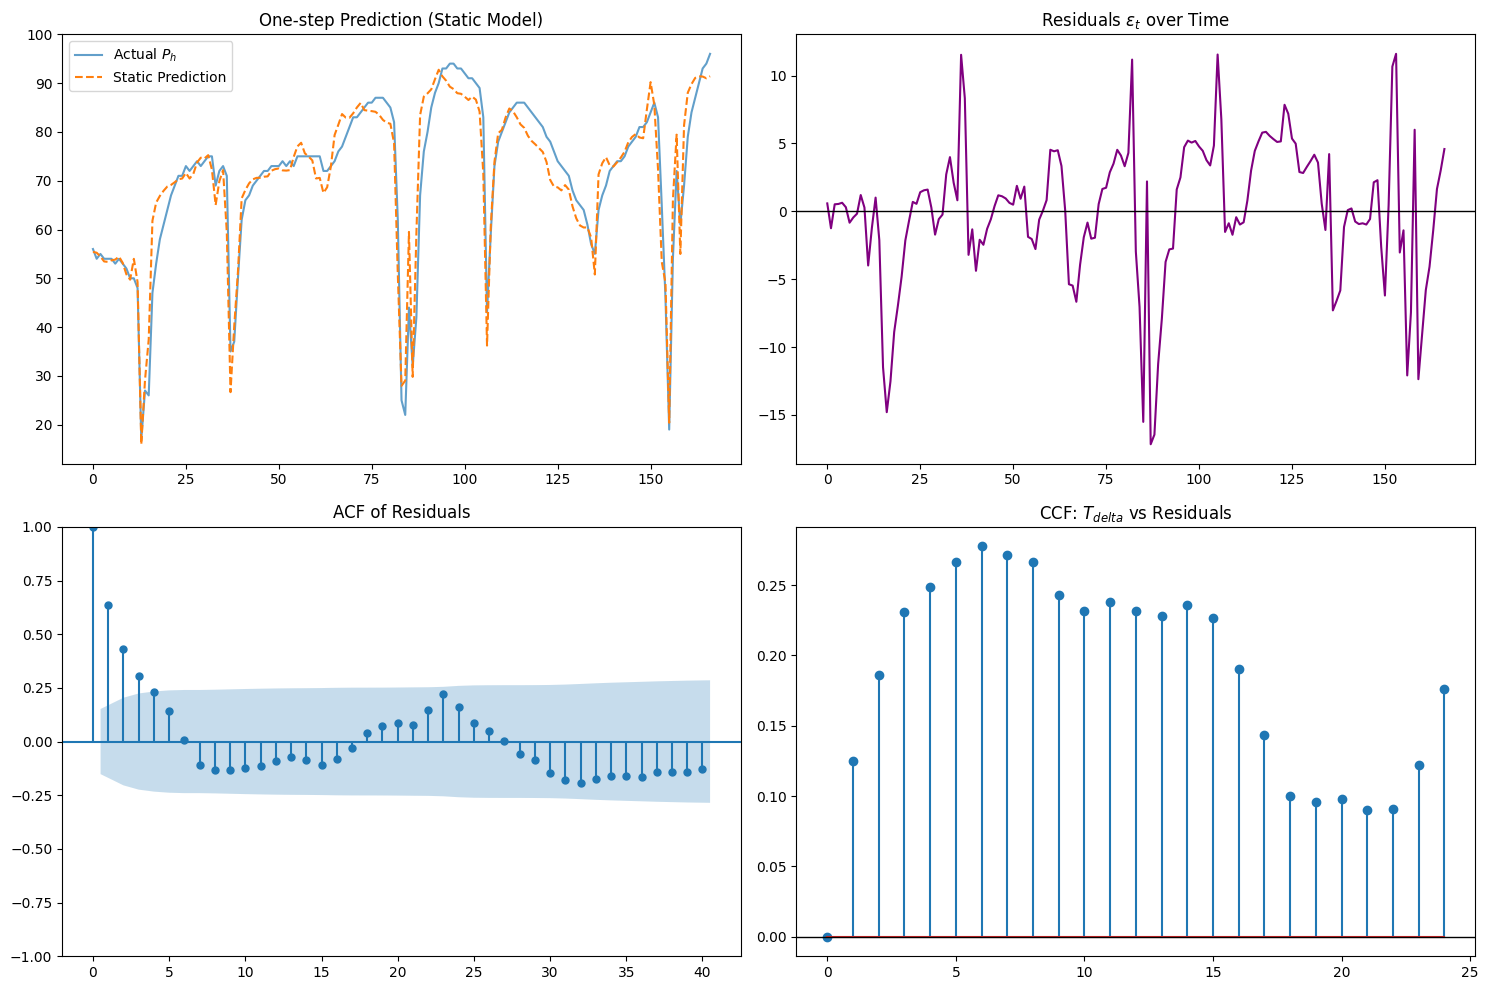

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time Series Plot: Actual vs Predicted
axes[0,0].plot(train_df.index, train_df['Ph'], label='Actual $P_h$', alpha=0.7)
axes[0,0].plot(train_df.index, train_df['pred_static'], label='Static Prediction', linestyle='--')
axes[0,0].set_title('One-step Prediction (Static Model)')
axes[0,0].legend()

# Residuals over time
axes[0,1].plot(train_df.index, train_df['residuals'], color='purple')
axes[0,1].axhline(0, color='black', lw=1)
axes[0,1].set_title('Residuals $\epsilon_t$ over Time')

# ACF of Residuals (Check for independence)
plot_acf(train_df['residuals'], lags=40, ax=axes[1,0], title='ACF of Residuals')

# CCF between Tdelta and Residuals (Check for unmodeled dynamics)
# Manual CCF calculation for residuals
res_ccf = [train_df['residuals'].corr(train_df['Tdelta'].shift(i)) for i in range(25)]
axes[1,1].stem(range(25), res_ccf)
axes[1,1].axhline(0, color='black', lw=1)
axes[1,1].set_title('CCF: $T_{delta}$ vs Residuals')

plt.tight_layout()
plt.show()